In [ ]:
!pip install nltk scikit-learn pandas numpy ipywidgets -q

In [ ]:
import nltk
import re
import random
import string
import warnings
import pandas as pd
import numpy as np

warnings.filterwarnings("ignore")

# NLP
from nltk.tokenize import word_tokenize
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer

# ML
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics.pairwise import cosine_similarity

nltk.download('punkt', quiet=True)
nltk.download('punkt_tab', quiet=True)
nltk.download('wordnet', quiet=True)
nltk.download('stopwords', quiet=True)


try:
    from sentence_transformers import SentenceTransformer

    SBERT_MODEL = SentenceTransformer('all-MiniLM-L6-v2')
    USE_SBERT = True

except Exception as e:
    USE_SBERT = False

Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]

BertModel LOAD REPORT from: sentence-transformers/all-MiniLM-L6-v2
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


In [ ]:
# DATASET TIKET PESAWAT
# Disesuaikan dengan data penjualan_tiket_pesawat.csv
# Maskapai: Garuda, Citilink, Lion Air
# Kota    : Jakarta, Medan, Surabaya
# Bayar   : E-Wallet, Transfer Bank, Credit Card

flight_qa_data = [
    # ── HARGA ──
    {"category": "harga", "question": "berapa harga tiket pesawat dari jakarta",
     "answer": "Berdasarkan data penjualan, rata-rata harga tiket pesawat dari Jakarta sekitar Rp1.206.583. Harga bervariasi tergantung maskapai dan waktu pemesanan."},
    {"category": "harga", "question": "berapa harga tiket pesawat dari medan",
     "answer": "Berdasarkan data penjualan, rata-rata harga tiket pesawat dari Medan sekitar Rp1.247.802. Tersedia maskapai Garuda, Citilink, dan Lion Air."},
    {"category": "harga", "question": "berapa harga tiket pesawat dari surabaya",
     "answer": "Berdasarkan data penjualan, rata-rata harga tiket pesawat dari Surabaya sekitar Rp1.294.778. Harga tergantung maskapai dan tanggal keberangkatan."},
    {"category": "harga", "question": "berapa harga tiket garuda indonesia",
     "answer": "Harga tiket Garuda Indonesia rata-rata sekitar Rp1.263.633. Garuda merupakan maskapai full service dengan layanan premium."},
    {"category": "harga", "question": "berapa harga tiket citilink",
     "answer": "Harga tiket Citilink rata-rata sekitar Rp1.238.239. Citilink adalah maskapai low cost carrier (LCC) yang terjangkau."},
    {"category": "harga", "question": "berapa harga tiket lion air",
     "answer": "Harga tiket Lion Air rata-rata sekitar Rp1.249.858. Lion Air adalah maskapai low cost carrier populer di Indonesia."},
    {"category": "harga", "question": "tiket pesawat murah jakarta medan surabaya",
     "answer": "Tiket pesawat antara Jakarta, Medan, dan Surabaya tersedia mulai sekitar Rp509.210. Pilih Citilink atau Lion Air untuk harga lebih terjangkau."},
    {"category": "harga", "question": "bagaimana cara mendapatkan tiket pesawat paling murah",
     "answer": "Tips mendapatkan tiket murah: (1) Pesan 1-2 bulan sebelum keberangkatan, (2) Pilih maskapai LCC seperti Citilink atau Lion Air, (3) Manfaatkan promo flash sale."},

    # ── MASKAPAI ──
    {"category": "maskapai", "question": "maskapai apa saja yang tersedia",
     "answer": "Maskapai yang tersedia: Garuda Indonesia (full service), Citilink (low cost), dan Lion Air (low cost). Semua melayani rute Jakarta, Medan, dan Surabaya."},
    {"category": "maskapai", "question": "maskapai terbaik garuda citilink lion air mana yang bagus",
     "answer": "Dari data penjualan: Garuda (184 transaksi) unggul di layanan premium, Citilink (154 transaksi) dan Lion Air (162 transaksi) populer sebagai pilihan ekonomis."},
    {"category": "maskapai", "question": "perbedaan garuda dan citilink dan lion air",
     "answer": "Garuda Indonesia: maskapai full service, harga premium. Citilink & Lion Air: maskapai low cost carrier (LCC), harga lebih terjangkau namun fasilitas lebih terbatas."},
    {"category": "maskapai", "question": "apa itu low cost carrier maskapai murah",
     "answer": "Low Cost Carrier (LCC) adalah maskapai dengan harga tiket lebih murah, biasanya tanpa fasilitas tambahan seperti bagasi gratis dan makanan. Contoh: Citilink dan Lion Air."},

    # ── RUTE ──
    {"category": "rute", "question": "rute penerbangan yang tersedia jakarta medan surabaya",
     "answer": "Rute penerbangan yang tersedia mencakup kota Jakarta, Medan, dan Surabaya. Tersedia penerbangan antar ketiga kota tersebut dengan Garuda, Citilink, dan Lion Air."},
    {"category": "rute", "question": "penerbangan dari jakarta ke medan",
     "answer": "Penerbangan dari Jakarta ke Medan tersedia melalui Garuda, Citilink, dan Lion Air. Rata-rata harga tiket sekitar Rp1.200.000 - Rp1.300.000."},
    {"category": "rute", "question": "penerbangan dari jakarta ke surabaya",
     "answer": "Penerbangan dari Jakarta ke Surabaya tersedia melalui Garuda, Citilink, dan Lion Air. Rata-rata harga tiket sekitar Rp1.200.000 - Rp1.300.000."},
    {"category": "rute", "question": "penerbangan dari medan ke surabaya",
     "answer": "Penerbangan dari Medan ke Surabaya tersedia dengan beberapa pilihan maskapai. Cek ketersediaan di website maskapai atau aplikasi travel."},

    # ── PEMBAYARAN ──
    {"category": "pembayaran", "question": "metode pembayaran apa yang tersedia untuk beli tiket",
     "answer": "Metode pembayaran yang tersedia: E-Wallet (paling populer, 187 transaksi), Credit Card (157 transaksi), dan Transfer Bank (156 transaksi)."},
    {"category": "pembayaran", "question": "bisa bayar tiket pesawat pakai e-wallet",
     "answer": "Ya! E-Wallet adalah metode pembayaran paling populer untuk tiket pesawat, mencakup sekitar 37% dari total transaksi."},
    {"category": "pembayaran", "question": "bisa bayar tiket pesawat pakai kartu kredit credit card",
     "answer": "Ya, pembayaran dengan kartu kredit (Credit Card) tersedia dan mencakup sekitar 31% transaksi. Kadang ada promo cashback khusus kartu kredit tertentu."},
    {"category": "pembayaran", "question": "bisa bayar tiket pesawat pakai transfer bank",
     "answer": "Ya, Transfer Bank tersedia sebagai metode pembayaran (sekitar 31% transaksi). Pastikan transfer dalam waktu yang ditentukan agar pemesanan tidak dibatalkan."},

    # ── JADWAL ──
    {"category": "jadwal", "question": "jadwal penerbangan garuda indonesia",
     "answer": "Jadwal Garuda Indonesia bervariasi setiap hari. Silakan cek website resmi Garuda atau aplikasi travel untuk jadwal terbaru sesuai rute yang diinginkan."},
    {"category": "jadwal", "question": "jadwal penerbangan lion air hari ini",
     "answer": "Jadwal Lion Air berbeda setiap hari. Silakan cek website resmi atau aplikasi untuk jadwal terbaru sesuai rute yang diinginkan."},
    {"category": "jadwal", "question": "jadwal penerbangan citilink",
     "answer": "Jadwal Citilink dapat dilihat di website citilink.co.id atau aplikasi travel. Citilink melayani rute Jakarta, Medan, dan Surabaya."},

    # ── BOOKING ──
    {"category": "booking", "question": "cara pesan tiket pesawat online langkah langkah",
     "answer": "Cara booking tiket: (1) Pilih rute dan tanggal, (2) Isi data penumpang, (3) Pilih kursi (opsional), (4) Pembayaran via E-Wallet/Kartu Kredit/Transfer Bank, (5) E-ticket dikirim via email."},
    {"category": "booking", "question": "apakah bisa pilih kursi saat booking tiket",
     "answer": "Ya, beberapa maskapai memungkinkan pemilihan kursi saat booking, namun bisa dikenakan biaya tambahan."},

    # ── BAGASI ──
    {"category": "bagasi", "question": "berapa kg bagasi gratis pesawat domestik",
     "answer": "Bagasi gratis biasanya 15-20 kg untuk penerbangan domestik. Garuda biasanya 20 kg, LCC seperti Citilink dan Lion Air bisa berbeda atau tidak termasuk bagasi."},
    {"category": "bagasi", "question": "apa itu bagasi kabin pesawat",
     "answer": "Bagasi kabin adalah barang bawaan yang dibawa masuk ke pesawat, biasanya maksimal 7 kg dengan dimensi tertentu."},

    # ── REFUND ──
    {"category": "refund", "question": "cara refund tiket pesawat",
     "answer": "Refund tiket dapat dilakukan melalui aplikasi atau website tempat pembelian. Syarat dan ketentuan tergantung kebijakan maskapai (Garuda, Citilink, atau Lion Air)."},
    {"category": "refund", "question": "apakah tiket pesawat bisa di reschedule ubah jadwal",
     "answer": "Ya, tiket bisa diubah jadwal (reschedule) tergantung jenis tiket dan mungkin dikenakan biaya tambahan. Cek kebijakan masing-masing maskapai."},

    # ── PROMO ──
    {"category": "promo", "question": "promo diskon tiket pesawat murah",
     "answer": "Promo tiket pesawat biasanya tersedia saat Harbolnas, flash sale maskapai, atau promo kartu kredit. Pantau website Garuda, Citilink, dan Lion Air secara rutin."},
    {"category": "promo", "question": "cara dapat diskon tiket pesawat promo",
     "answer": "Tips diskon: Gunakan kode promo, bayar dengan kartu kredit yang punya cashback, atau booking lewat aplikasi travel yang sering ada promo."},

    # ── BANDARA ──
    {"category": "bandara", "question": "bandara di jakarta apa saja",
     "answer": "Bandara utama di Jakarta adalah Soekarno-Hatta (CGK) dan Halim Perdanakusuma (HLP). Garuda, Citilink, dan Lion Air beroperasi di Soekarno-Hatta."},
    {"category": "bandara", "question": "berapa jam sebelum penerbangan harus di bandara",
     "answer": "Disarankan tiba di bandara 2 jam sebelum keberangkatan untuk penerbangan domestik, agar cukup waktu untuk check-in dan pemeriksaan keamanan."},

    # ── UMUM ──
    {"category": "umum", "question": "apa itu e ticket pesawat",
     "answer": "E-ticket adalah tiket elektronik yang berisi detail penerbangan dan digunakan saat check-in. Bisa ditunjukkan lewat hp atau dicetak."},
    {"category": "umum", "question": "apa yang harus dibawa saat naik pesawat dokumen",
     "answer": "Dokumen penting: KTP/Paspor, e-ticket, dan bagasi sesuai aturan maskapai (Garuda, Citilink, atau Lion Air)."},
    {"category": "umum", "question": "topik apa saja yang bisa ditanyakan capability chatbot",
     "answer": "Chatbot ini membantu topik: harga tiket, maskapai (Garuda/Citilink/Lion Air), rute (Jakarta/Medan/Surabaya), pembayaran (E-Wallet/Kartu Kredit/Transfer Bank), jadwal, booking, bagasi, refund, dan promo."},
    {"category": "umum", "question": "tidak tahu tidak mengerti pertanyaan tidak relevan",
     "answer": "Maaf, saya tidak menemukan informasi yang sesuai. Silakan tanya seputar tiket pesawat, maskapai, harga, jadwal, atau booking."},
]

# Membuat DataFrame
df = pd.DataFrame(flight_qa_data)

print(f"Dataset berhasil dimuat!")
print(f"Total pasangan Q&A: {len(df)}")
print(f"Kategori: {', '.join(df['category'].unique())}")
print("\n 5 contoh data pertama:")
df[['category', 'question']].head()

Dataset berhasil dimuat!
Total pasangan Q&A: 37
Kategori: harga, maskapai, rute, pembayaran, jadwal, booking, bagasi, refund, promo, bandara, umum

 5 contoh data pertama:


,category,question
0,harga,berapa harga tiket pesawat dari jakarta
1,harga,berapa harga tiket pesawat dari medan
2,harga,berapa harga tiket pesawat dari surabaya
3,harga,berapa harga tiket garuda indonesia
4,harga,berapa harga tiket citilink


In [ ]:
lemmatizer = WordNetLemmatizer()

# Stopwords khusus chatbot tiket pesawat
indonesian_stopwords = {
    # kata umum
    'yang', 'dan', 'di', 'ke', 'dari', 'ini', 'itu', 'dengan', 'untuk',
    'pada', 'adalah', 'atau', 'juga', 'dalam', 'tidak', 'akan', 'ada',

    # kata orang
    'saya', 'kamu', 'anda', 'ia', 'mereka', 'kami', 'kita',

    # kata tanya (boleh dihapus biar fokus ke keyword penting)
    'apa', 'bagaimana', 'berapa', 'kapan', 'dimana', 'siapa', 'apakah', 'cara',

    # kata tambahan umum
    'lebih', 'sangat', 'dapat', 'nya', 'pun', 'lagi', 'belum',
    'telah', 'namun', 'tapi', 'serta', 'meski', 'agar', 'supaya', 'hal',

    # kata umum di pertanyaan tiket
    'mau', 'ingin', 'cari', 'tanya', 'info', 'informasi',
    'dong', 'nih', 'ya', 'aja', 'kok',

    # bahasa inggris umum
    'the', 'is', 'are', 'was', 'what', 'how', 'why', 'when', 'where'
}

english_stopwords = set(stopwords.words('english'))
all_stopwords = indonesian_stopwords.union(english_stopwords)

def preprocess_text(text):
    text = text.lower()
    text = re.sub(r'[^\w\s]', '', text)

    tokens = word_tokenize(text)
    tokens = [t for t in tokens if t not in all_stopwords and len(t) > 2]
    tokens = [lemmatizer.lemmatize(t) for t in tokens]

    return ' '.join(tokens)

print("Test preprocessing")
for t in [ "harga tiket",
    "jadwal penerbangan",
    "maskapai",
    "booking tiket",
    "promo pesawat"]:
    print(f" '{t}'-> '{preprocess_text(t)}'")

df['processed_question'] = df['question'].apply(preprocess_text)


Test preprocessing
 'harga tiket'-> 'harga tiket'
 'jadwal penerbangan'-> 'jadwal penerbangan'
 'maskapai'-> 'maskapai'
 'booking tiket'-> 'booking tiket'
 'promo pesawat'-> 'promo pesawat'


In [ ]:
import re
import random
import numpy as np
from sklearn.metrics.pairwise import cosine_similarity
from sklearn.feature_extraction.text import TfidfVectorizer

USE_SBERT = False


# =========================
# PREPROCESS
# =========================
def preprocess_text(text):
    return text.lower()


# =========================
# MAIN CLASS
# =========================
class FlightChatbotEngineV3:

    def __init__(self, dataframe, threshold=0.15, top_k=3):
        self.df = dataframe
        self.threshold = threshold
        self.top_k = top_k
        self.conversation_history = []
        self._build_index()
        self._define_rules()

    def _build_index(self):
        self.vectorizer = TfidfVectorizer(
            ngram_range=(1, 2),
            max_features=5000,
            sublinear_tf=True
        )
        self.tfidf_matrix = self.vectorizer.fit_transform(
            self.df['processed_question']
        )

    def _define_rules(self):
        # Format: (label_display, df_category, regex_pattern)
        self.rules = [
            ('rute populer',       'rute',     r'(jakarta.*medan|jakarta.*surabaya|medan.*surabaya|rute penerbangan)'),
            ('harga tiket',        'harga',    r'(harga|murah|termurah|biaya|berapa|pesan tiket)'),
            ('jadwal penerbangan', 'jadwal',   r'(jadwal|ada penerbangan|penerbangan pagi|penerbangan siang|penerbangan malam|jam berangkat)'),
            ('maskapai terbaik',   'maskapai', r'(maskapai|garuda|batik air|citilink|lion air|terbaik|lebih nyaman|lebih bagus)'),
            ('promo & diskon',     'promo',    r'(promo|diskon|sale|cashback|akhir pekan)'),
            ('greeting',           None,       r'(halo|hai|\bhi\b|hello|selamat pagi|selamat siang|selamat malam)'),
            ('capability',         None,       r'(bisa apa|fitur|topik apa|apa saja yang bisa|yang bisa dicari)'),
            ('unknown',            None,       r'(xyzabc)'),
        ]

    def _check_rules(self, text):
        text_lower = text.lower()

        for label, df_category, pattern in self.rules:
            if re.search(pattern, text_lower):

                if label == 'greeting':
                    return "👋 Halo! Mau cari tiket ke mana hari ini?"

                if label == 'capability':
                    cap = self.df[
                        (self.df['category'] == 'umum') &
                        (self.df['question'].str.contains('topik|capability', na=False))
                    ]
                    if len(cap) > 0:
                        return f"[✈️ umum | RULE]\n\n{cap.iloc[0]['answer']}"
                    return "[✈️ umum | RULE]\n\nSaya bisa bantu cari tiket, harga, jadwal, maskapai, booking, promo, dan bagasi."

                if label == 'unknown':
                    return "🤔 Maaf, pertanyaan tidak dikenali."

                # ✅ filter pakai df_category yang sesuai kolom 'category'
                filtered = self.df[self.df['category'] == df_category]
                if len(filtered) > 0:
                    row = filtered.sample(1).iloc[0]
                    return f"[✈️ {label} | RULE]\n\n{row['answer']}"

        return None

    def _search_tfidf(self, query):
        processed = preprocess_text(query)
        vec = self.vectorizer.transform([processed])
        scores = cosine_similarity(vec, self.tfidf_matrix).flatten()
        top_results = np.argsort(scores)[::-1][:self.top_k]
        return [(idx, scores[idx]) for idx in top_results]

    def _find_best_match(self, query):
        results = self._search_tfidf(query)
        return results[0]

    def get_response(self, user_input):
        if not user_input.strip():
            return "Masukkan pertanyaan"

        rule_response = self._check_rules(user_input)
        if rule_response:
            return rule_response

        results = self._search_tfidf(user_input)
        best_idx, best_score = results[0]
        row = self.df.iloc[best_idx]

        if best_score < self.threshold or row['category'] == 'umum':
            return "🤔 Maaf, aku belum menemukan info yang cocok."

        self.conversation_history.append(user_input)
        return (
            f"[✈️ {row['category']} | TF-IDF]\n\n"
            f"{row['answer']}\n\n"
            f"-----------------\n"
            f"💡 Tips: Cek harga di beberapa hari untuk dapat tiket termurah."
        )


bot = FlightChatbotEngineV3(df)

In [ ]:
# =========================
# UI CHATBOT INTERAKTIF (FLIGHT BOT) + BOT ASLI
# =========================

import ipywidgets as widgets
from IPython.display import display, HTML, clear_output

USE_SBERT = False  # samakan dengan engine

chat_css = """
<style>
  @import url('https://fonts.googleapis.com/css2?family=Plus+Jakarta+Sans:wght@400;500;600;700&display=swap');
  .medbot-container { font-family: 'Plus Jakarta Sans', sans-serif; max-width: 720px; margin: 0 auto; border-radius: 20px; overflow: hidden; box-shadow: 0 20px 60px rgba(0,0,0,0.15); background: #f8faff; }
  .medbot-header { background: linear-gradient(135deg, #0f172a 0%, #1e3a8a 50%, #2563eb 100%); padding: 20px 24px; color: white; display: flex; align-items: center; gap: 14px; }
  .medbot-avatar { width: 48px; height: 48px; background: rgba(255,255,255,0.2); border-radius: 50%; display: flex; align-items: center; justify-content: center; font-size: 24px; border: 2px solid rgba(255,255,255,0.4); }
  .medbot-title { font-size: 18px; font-weight: 700; }
  .medbot-subtitle { font-size: 12px; opacity: 0.75; margin-top: 2px; }
  .status-dot { width:8px; height:8px; background:#4ade80; border-radius:50%; display:inline-block; margin-right:5px; animation: pulse 2s infinite; }
  @keyframes pulse { 0%,100%{opacity:1} 50%{opacity:0.5} }
  .medbot-chat { height: 400px; overflow-y: auto; padding: 20px; background: #f0f4ff; display: flex; flex-direction: column; gap: 14px; }
  .message-row-user { display:flex; justify-content:flex-end; }
  .message-row-bot  { display:flex; justify-content:flex-start; align-items:flex-start; gap:10px; }
  .bot-icon { width: 32px; height: 32px; min-width: 32px; background: linear-gradient(135deg, #2563eb, #1e3a8a); border-radius: 50%; display: flex; align-items:center; justify-content:center; font-size: 14px; }
  .bubble-user { background: linear-gradient(135deg, #2563eb, #1e3a8a); color: white; padding: 12px 16px; border-radius: 18px 18px 4px 18px; max-width: 75%; font-size: 14px; }
  .bubble-bot { background: white; color: #1a1a2e; padding: 12px 16px; border-radius: 18px 18px 18px 4px; max-width: 80%; font-size: 13.5px; box-shadow: 0 2px 10px rgba(0,0,0,0.08); border: 1px solid #e8eeff; white-space: pre-wrap; }
</style>
"""

chat_messages = []

# =========================
# 🔥 INISIALISASI BOT ASLI
# =========================
# Pastikan df sudah ada!
bot = FlightChatbotEngineV3(df)

# =========================
# RENDER CHAT
# =========================
def render_chat():
    mode_badge = (
        '<span style="background:#d1fae5;color:#065f46;border-radius:12px;padding:2px 8px;font-size:10px;">SBERT</span>'
        if USE_SBERT else
        '<span style="background:#fee2e2;color:#991b1b;border-radius:12px;padding:2px 8px;font-size:10px;">TF-IDF</span>'
    )

    html = chat_css
    html += '<div class="medbot-container">'

    html += f'''
    <div class="medbot-header">
      <div class="medbot-avatar">✈️</div>
      <div>
        <div class="medbot-title">FlightBot v3 {mode_badge}</div>
        <div class="medbot-subtitle">Online · Flight Search Engine</div>
      </div>
    </div>
    '''

    html += '<div class="medbot-chat">'

    if not chat_messages:
        html += '''
        <div class="message-row-bot">
          <div class="bot-icon">🤖</div>
          <div class="bubble-bot">
👋 Halo! Saya FlightBot ✈️
Coba tanya: "tiket jakarta ke medan"
          </div>
        </div>
        '''

    for msg in chat_messages:
        if msg['role'] == 'user':
            html += f'<div class="message-row-user"><div class="bubble-user">{msg["content"]}</div></div>'
        else:
            html += f'<div class="message-row-bot"><div class="bot-icon">🤖</div><div class="bubble-bot">{msg["content"]}</div></div>'

    html += '</div></div>'
    return HTML(html)

# =========================
# INPUT
# =========================
text_input = widgets.Text(
    placeholder='Contoh: tiket jakarta ke surabaya',
    layout=widgets.Layout(width='80%')
)

send_button = widgets.Button(description='Kirim ✈️')
clear_button = widgets.Button(description='Clear')

output_area = widgets.Output()

def send_message(b=None):
    global chat_messages
    user_text = text_input.value.strip()
    if not user_text:
        return

    chat_messages.append({'role': 'user', 'content': user_text})

    # 🔥 PAKAI BOT ASLI
    response = bot.get_response(user_text)

    chat_messages.append({'role': 'bot', 'content': response})

    text_input.value = ''

    with output_area:
        clear_output(wait=True)
        display(render_chat())

def clear_chat(b):
    global chat_messages
    chat_messages = []
    bot.conversation_history = []  # reset context juga

    with output_area:
        clear_output(wait=True)
        display(render_chat())

send_button.on_click(send_message)
clear_button.on_click(clear_chat)
text_input.on_submit(lambda w: send_message())

input_bar = widgets.HBox([text_input, send_button, clear_button])

with output_area:
    display(render_chat())

display(output_area)
display(input_bar)


Output()

In [ ]:
import gradio as gr
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics.pairwise import cosine_similarity

bot = FlightChatbotEngineV3(df)

def respond(message, history):
  if history is None:
    history = []

  history.append((message, "MedBot sedang mengetik"))
  yield "", history

  time.sleep(0.6)
  response = bot.get_response(message)

  history[-1] = (message, response)
  yield "", history

In [ ]:
def respond_chip(message, history):
    if history is None:
        history = []

    response = bot.get_response(message)
    history.append((message, response))
    return "", history

In [50]:
import gradio as gr

# =========================
# BOT (PASTIKAN INI SUDAH ADA)
# =========================
# bot = FlightChatbotEngineV3(df)


# =========================
# RESPOND (SUPER SAFE)
# =========================
def respond(message, chat_history):
    # pastikan history list
    if not isinstance(chat_history, list):
        chat_history = []

    clean_history = []

    # normalize history (biar gak campur format)
    for msg in chat_history:
        if isinstance(msg, dict):
            clean_history.append({
                "role": msg.get("role", "assistant"),
                "content": str(msg.get("content", ""))
            })
        elif isinstance(msg, (list, tuple)) and len(msg) == 2:
            clean_history.append({
                "role": "user",
                "content": str(msg[0])
            })
            clean_history.append({
                "role": "assistant",
                "content": str(msg[1])
            })

    # =========================
    # AMBIL RESPONSE BOT
    # =========================
    try:
        response = bot.get_response(message)
    except Exception as e:
        response = f"Error bot: {str(e)}"

    # FIX KRITIS (hindari _id error)
    response = str(response)

    # append user
    clean_history.append({
        "role": "user",
        "content": str(message)
    })

    # append bot
    clean_history.append({
        "role": "assistant",
        "content": response
    })

    return "", clean_history


# =========================
# CLEAR CHAT
# =========================
def clear_chat():
    try:
        bot.conversation_history = []
    except:
        pass
    return []


# =========================
# UI
# =========================
with gr.Blocks() as demo:
    gr.Markdown("## ✈️ FlightBot v3 — Flight Assistant")

    chatbot = gr.Chatbot(type="messages")  # WAJIB
    msg = gr.Textbox(placeholder="Ketik pertanyaan...")

    with gr.Row():
        send = gr.Button("Kirim")
        clear = gr.Button("Clear")

    with gr.Row():
        chip1 = gr.Button("Jakarta ke Surabaya")
        chip2 = gr.Button("Tiket murah")
        chip3 = gr.Button("Jadwal penerbangan")
        chip4 = gr.Button("Maskapai terbaik")
        chip5 = gr.Button("Harga tiket")

    # =========================
    # EVENT
    # =========================
    send.click(respond, [msg, chatbot], [msg, chatbot])
    msg.submit(respond, [msg, chatbot], [msg, chatbot])

    clear.click(clear_chat, None, chatbot, queue=False)

    # CHIP (AMAN)
    chip1.click(lambda h: respond("tiket jakarta ke surabaya", h), chatbot, [msg, chatbot])
    chip2.click(lambda h: respond("tiket murah", h), chatbot, [msg, chatbot])
    chip3.click(lambda h: respond("jadwal penerbangan", h), chatbot, [msg, chatbot])
    chip4.click(lambda h: respond("maskapai terbaik", h), chatbot, [msg, chatbot])
    chip5.click(lambda h: respond("harga tiket", h), chatbot, [msg, chatbot])


# =========================
# LAUNCH
# =========================
demo.queue()
demo.launch()


It looks like you are running Gradio on a hosted Jupyter notebook, which requires `share=True`. Automatically setting `share=True` (you can turn this off by setting `share=False` in `launch()` explicitly).

Colab notebook detected. To show errors in colab notebook, set debug=True in launch()

Could not create share link. Please check your internet connection or our status page: https://status.gradio.app.


2026/04/01 14:50:02 [W] [service.go:132] login to server failed: session shutdown


<IPython.core.display.Javascript object>

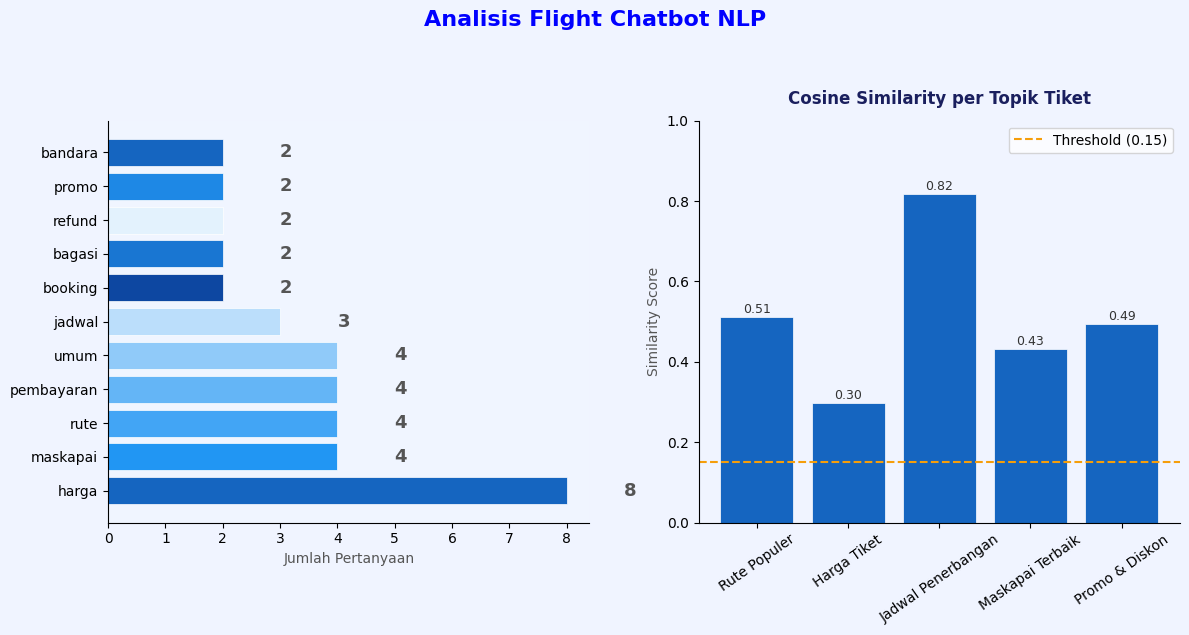

In [51]:
import matplotlib.pyplot as plt

# Ambil jumlah pertanyaan per kategori (JANGAN DIUBAH)
category_counts = df['category'].value_counts()

# Buat figure
fig, axes = plt.subplots(1, 2, figsize=(12, 6))
fig.patch.set_facecolor('#f0f4ff')
plt.suptitle('Analisis Flight Chatbot NLP', fontsize=16, fontweight='bold', color='blue', y=1.05)

# =========================
# Grafik 1: Jumlah Pertanyaan per Kategori
# =========================
colors = ['#1565c0', '#2196f3', '#42a5f5', '#64b5f6', '#90caf9',
          '#bbdefb', '#0d47a1', '#1976d2', '#e3f2fd', '#1e88e5']

axes[0].barh(category_counts.index, category_counts.values,
             color=colors[:len(category_counts)], edgecolor='white', linewidth=0.5)
axes[0].set_xlabel('Jumlah Pertanyaan', color='#555')
axes[0].set_facecolor('#f0f5ff')
axes[0].spines['top'].set_visible(False)
axes[0].spines['right'].set_visible(False)

for i, v in enumerate(category_counts.values):
    axes[0].text(v + 1, i, str(v), va='center', fontsize=13, fontweight='bold', color='#555')

# =========================
# Grafik 2: Cosine Similarity (REAL dari BOT)
# =========================
test_cases = [
    ("tiket jakarta ke surabaya", "Rute Populer"),
    ("tiket murah hari ini", "Harga Tiket"),
    ("jadwal penerbangan garuda", "Jadwal Penerbangan"),
    ("maskapai terbaik jakarta-bali", "Maskapai Terbaik"),
    ("promo tiket akhir pekan", "Promo & Diskon"),
]

labels = []
scores = []

for query, label in test_cases:
    idx, score = bot._find_best_match(query)  # <- REAL SCORE
    labels.append(label)
    scores.append(score)

bar_colors = ['#1565c0' if s >= bot.threshold else '#ef5350' for s in scores]

bars = axes[1].bar(labels, scores, color=bar_colors, edgecolor='white', linewidth=0.5)

axes[1].axhline(
    y=bot.threshold,
    color='#f59e0b',
    linestyle='--',
    linewidth=1.5,
    label=f'Threshold ({bot.threshold})'
)

axes[1].set_title('Cosine Similarity per Topik Tiket', fontweight='bold', color='#1a1f5e', pad=12)
axes[1].set_ylabel('Similarity Score', color='#555')
axes[1].set_ylim(0, 1)
axes[1].set_facecolor('#f0f4ff')
axes[1].spines['top'].set_visible(False)
axes[1].spines['right'].set_visible(False)
axes[1].legend(fontsize=10)
axes[1].tick_params(axis='x', rotation=35)

for bar, score in zip(bars, scores):
    axes[1].text(
        bar.get_x() + bar.get_width()/2,
        bar.get_height() + 0.01,
        f'{score:.2f}',
        ha='center',
        fontsize=9,
        color='#333'
    )

plt.tight_layout()
plt.savefig('flightbot_analysis.png', dpi=150, bbox_inches='tight', facecolor='#f8faff')
plt.show()

In [52]:
# =========================
# EVALUASI LENGKAP — Test Case Tiket Penerbangan
# =========================

test_scenarios = [
    ("tiket jakarta ke surabaya besok", "rute populer", "Rute populer langsung"),
    ("pesan tiket murah hari ini", "harga tiket", "Harga tiket langsung"),
    ("jadwal penerbangan garuda indonesia", "jadwal penerbangan", "Jadwal langsung"),
    ("maskapai terbaik jakarta ke surabaya", "maskapai terbaik", "Maskapai terbaik"),
    ("promo tiket akhir pekan", "promo & diskon", "Promo dan diskon"),
    ("berapa harga tiket garuda hari ini", "harga tiket", "Harga tiket pertanyaan"),
    ("apakah ada penerbangan pagi dari jakarta?", "jadwal penerbangan", "Jadwal pagi"),
    ("garuda atau batik air lebih nyaman?", "maskapai terbaik", "Perbandingan maskapai"),
    ("tiket ke surabaya murah", "harga tiket", "Keyword murah"),
    ("halo selamat pagi", "greeting", "Salam"),
    ("topik apa saja yang bisa dicari", "capability", "Kemampuan bot"),
    ("ini pertanyaan yang tidak ada hubungannya xyzabc", "unknown", "Out-of-scope"),
]

print("=" * 70)
print("LAPORAN EVALUASI FLIGHTBOT v3")
print("=" * 70)

correct = 0

for user_input, expected_cat, description in test_scenarios:
    response = bot.get_response(user_input)
    response_lower = response.lower()
    is_correct = (
        expected_cat in response_lower or
        (expected_cat == 'greeting' and ('halo' in response_lower or 'hai' in response_lower)) or
        (expected_cat == 'capability' and 'topik' in response_lower) or
        (expected_cat == 'unknown' and ('tidak menemukan' in response_lower or 'tidak' in response_lower))
    )

    status = "✅" if is_correct else "❌"
    if is_correct:
        correct += 1

    print(f"\n{status} [{description}]")
    print(f"   Input   : '{user_input}'")
    print(f"   Expected: {expected_cat}")
    first_line = response.split('\n')[0]
    print(f"   Response: {first_line}")

accuracy = correct / len(test_scenarios) * 100
print("\n" + "=" * 70)
print(f"HASIL EVALUASI: {correct}/{len(test_scenarios)} benar ({accuracy:.1f}% akurasi)")
print("=" * 70)

LAPORAN EVALUASI FLIGHTBOT v3

✅ [Rute populer langsung]
   Input   : 'tiket jakarta ke surabaya besok'
   Expected: rute populer
   Response: [✈️ rute populer | RULE]

✅ [Harga tiket langsung]
   Input   : 'pesan tiket murah hari ini'
   Expected: harga tiket
   Response: [✈️ harga tiket | RULE]

✅ [Jadwal langsung]
   Input   : 'jadwal penerbangan garuda indonesia'
   Expected: jadwal penerbangan
   Response: [✈️ jadwal penerbangan | RULE]

❌ [Maskapai terbaik]
   Input   : 'maskapai terbaik jakarta ke surabaya'
   Expected: maskapai terbaik
   Response: [✈️ rute populer | RULE]

✅ [Promo dan diskon]
   Input   : 'promo tiket akhir pekan'
   Expected: promo & diskon
   Response: [✈️ promo & diskon | RULE]

✅ [Harga tiket pertanyaan]
   Input   : 'berapa harga tiket garuda hari ini'
   Expected: harga tiket
   Response: [✈️ harga tiket | RULE]

✅ [Jadwal pagi]
   Input   : 'apakah ada penerbangan pagi dari jakarta?'
   Expected: jadwal penerbangan
   Response: [✈️ jadwal penerbangan |